<a href="https://colab.research.google.com/github/ebuehrle/star-battle/blob/main/star_battle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q --upgrade cvxpy

In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

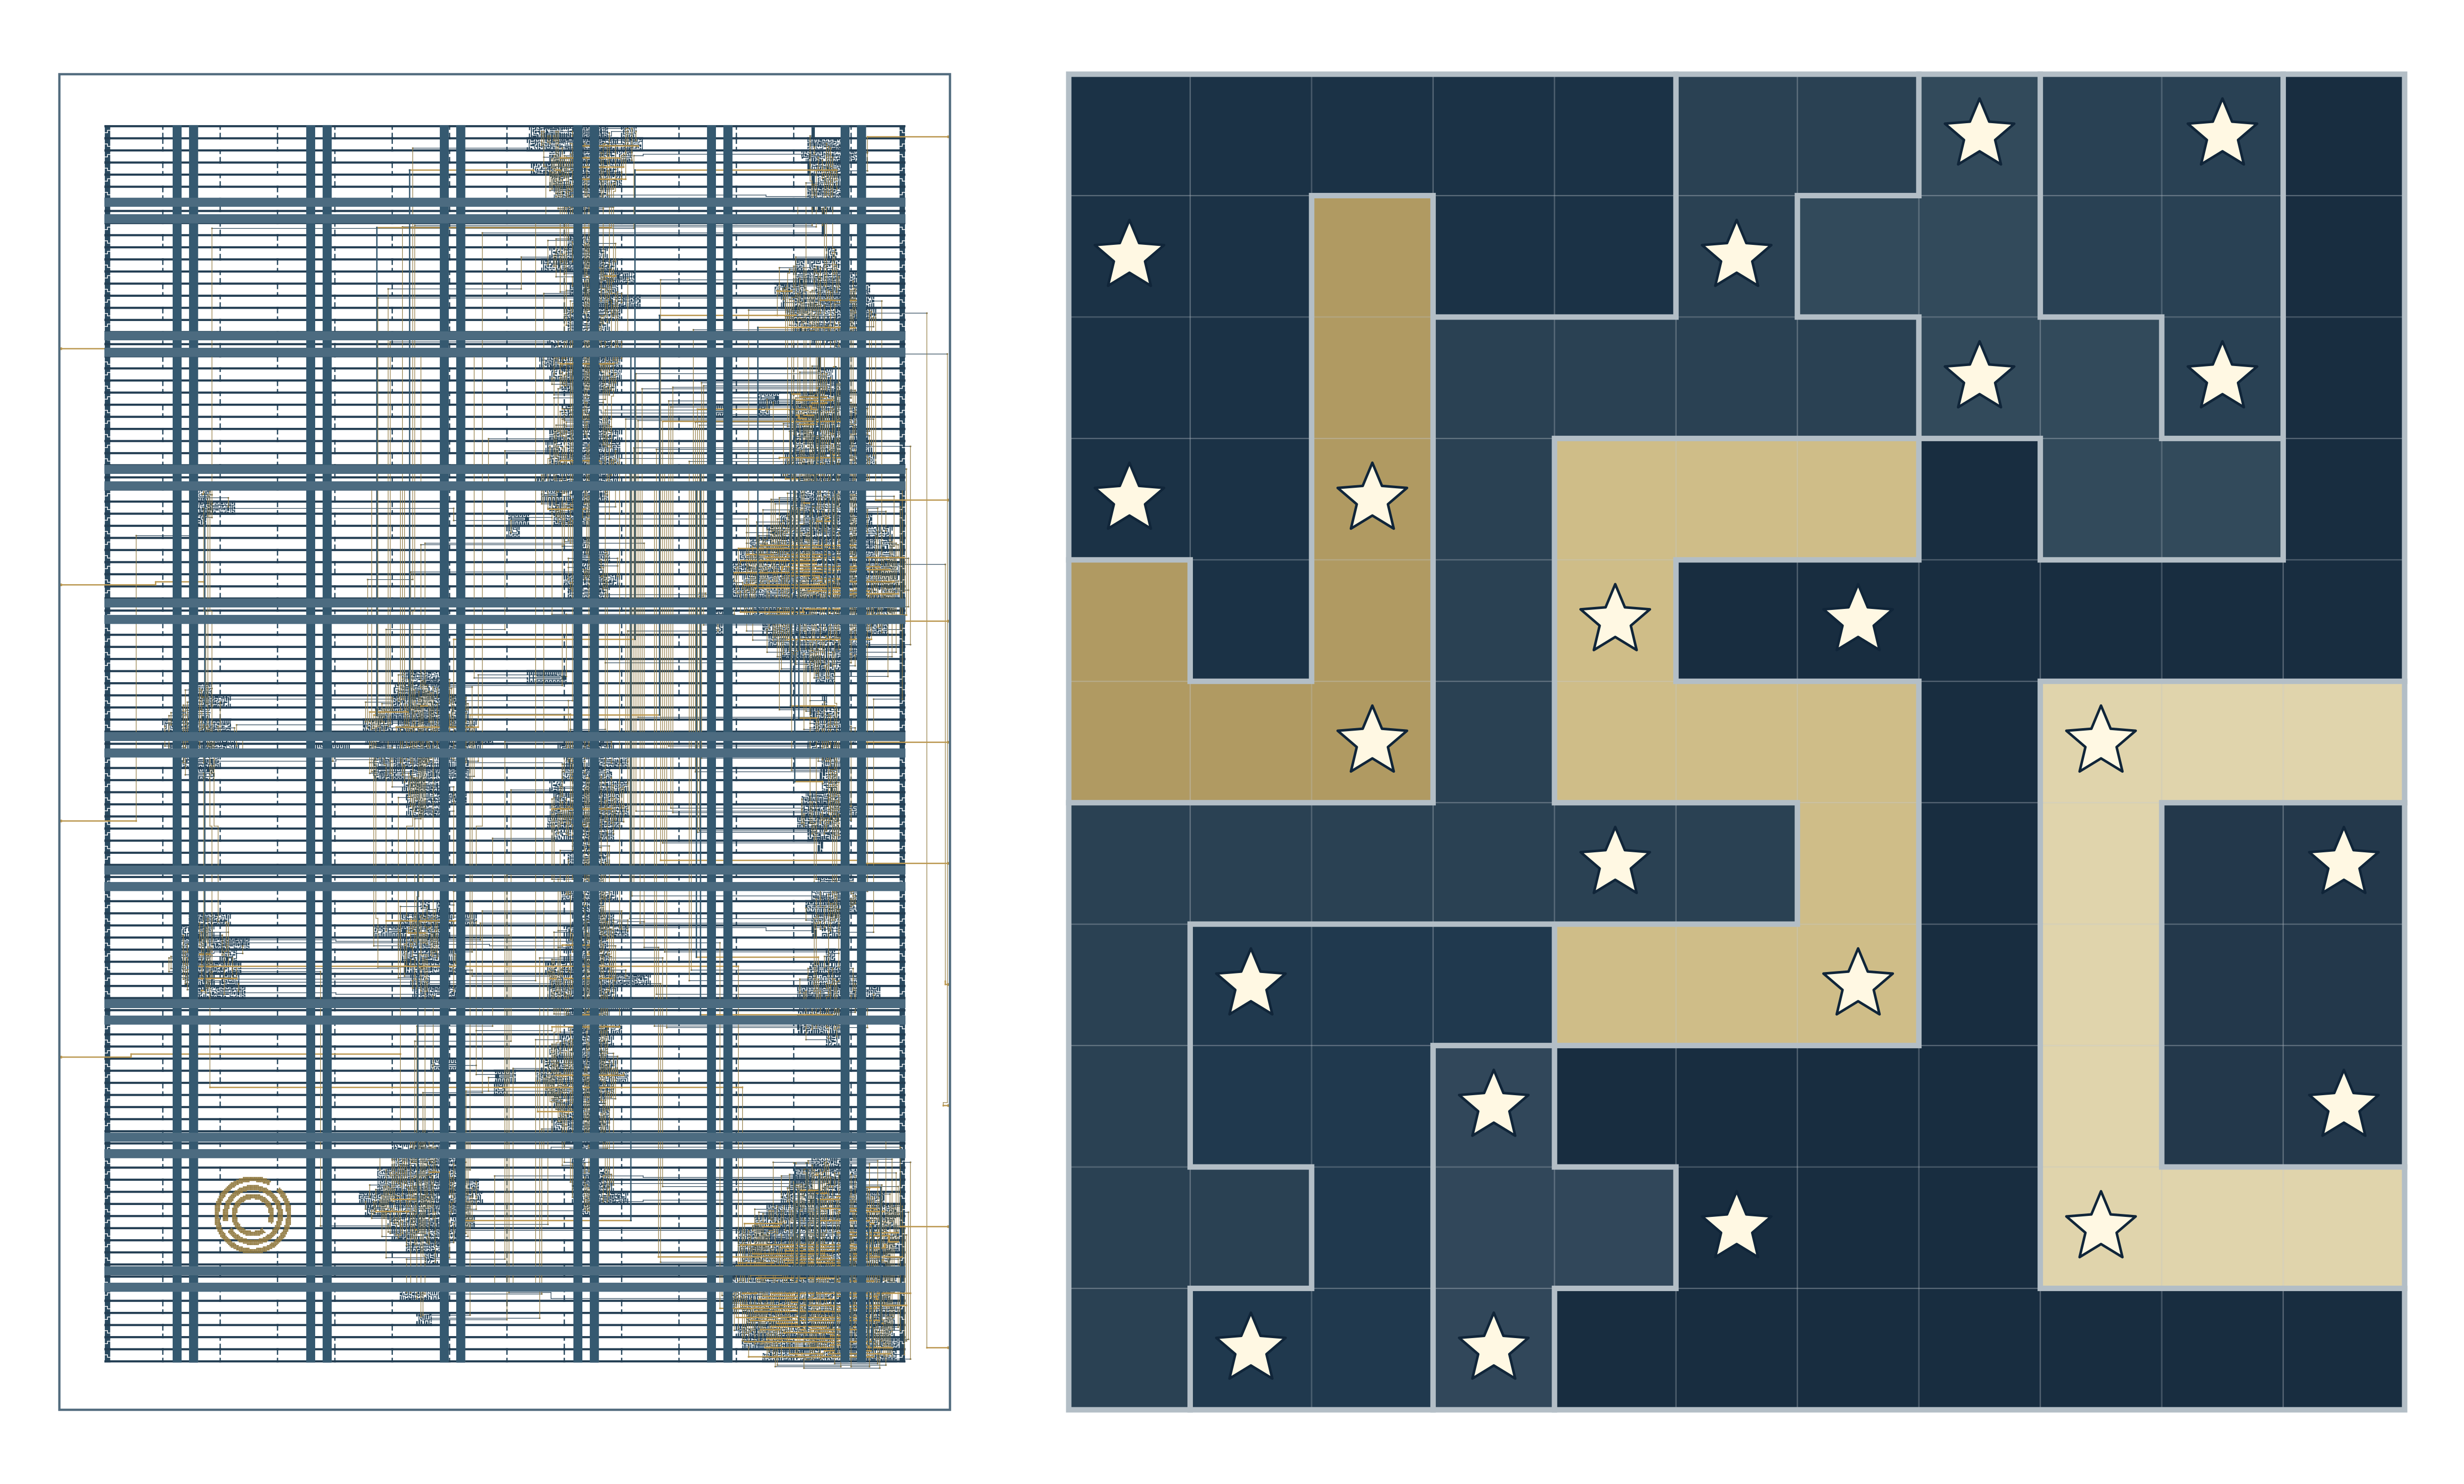

In [3]:
regions = np.array([
    [0,0,0,0,0,1,1,2,3,3,4,],
    [0,0,5,0,0,1,2,2,3,3,4,],
    [0,0,5,1,1,1,1,2,2,3,4,],
    [0,0,5,1,6,6,6,4,2,2,4,],
    [5,0,5,1,6,4,4,4,4,4,4,],
    [5,5,5,1,6,6,6,4,7,7,7,],
    [1,1,1,1,1,1,6,4,7,8,8,],
    [1,9,9,9,6,6,6,4,7,8,8,],
    [1,9,9,10,4,4,4,4,7,8,8,],
    [1,1,9,10,10,4,4,4,7,7,7,],
    [1,9,9,10,4,4,4,4,4,4,4,],
])

In [4]:
n_regions = regions.max().item() + 1
region = np.stack([regions == i for i in range(n_regions)], axis=0)

In [5]:
stars = cp.Variable(regions.shape, boolean=True)

In [6]:
p = cp.Problem(cp.Minimize(0), [
    stars.sum(0) == 2, # two stars per column
    stars.sum(1) == 2, # two stars per row
    cp.einsum('rxy,xy->r', region, stars) == 2, # two stars per region
    stars[:,:-1] + stars[:,1:] <= 1, # not touching horizontally
    stars[:-1,:] + stars[1:,:] <= 1, # not touching vertically
    stars[:-1,:-1] + stars[1:,1:] <= 1, # not touching diagonally
    stars[1:,:-1] + stars[:-1,1:] <= 1, # not touching antidiagonally
])

In [7]:
p.solve()

/tmp/ipykernel_2095/3098157749.py:1: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  p.solve()


0.0

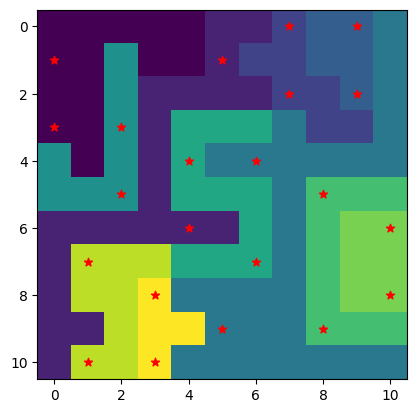

In [8]:
plt.imshow(regions)
plt.scatter(*np.where(stars.value.T), marker='*', color='red')